# Gaussian kernel clasification

Mucha veces cuando nosotros tratamos de usar los datos para clasificar 
dado SVM logramos ver que la data puede tender a ser no linea, en estos caso 
es imposible dada la logica de support vector machine encontrar los valores de 
los vectores para trasar una linea recta en el hiper plano, ya que la funcion tiende a mostrar 
de que los datos no son lineales.

en este caso nos podemos ayudar con el gaussian kernel para tratar de encontra la 
curva del plano y ajustar nuestra prediccion de la mejor manera.

ver ejemplo abajo

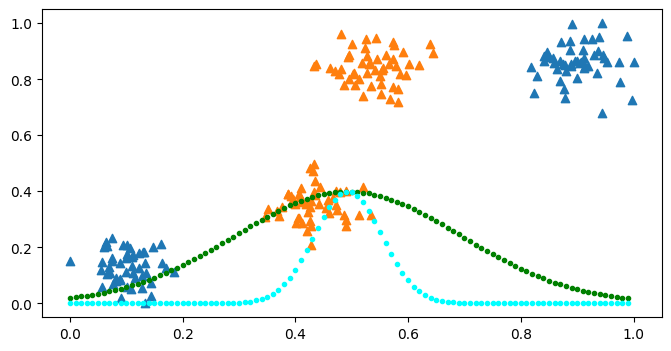

In [12]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import math
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# crear la funcion gaussiana
def gaussian(desviation):
    gaussian_y = []
    i = np.arange(0.0,1.0,0.01)
    for x in i:
        z = (x - mean_x)/desviation
        gaussian_y.append(kernel(z))
    return i, gaussian_y


def kernel(z):
    return math.exp(-(z*z)/2)/math.sqrt(2*math.pi)

plt.figure(figsize=(8,4))

CENTER = 4

X,y = make_blobs(n_samples=200,n_features=2,centers=CENTER,random_state=8,cluster_std=1)

y = y % 2

scaler = MinMaxScaler()
scaler.fit(X)
X = scaler.transform(X)


for target in range(CENTER):
    plt.scatter(X[y==target,1], X[y==target,0],marker='^',
                label='class ' +format(target))
    

mean_x = np.mean(X[:,1])
DESVIATION = 0.2

x, gaussian_y = gaussian(DESVIATION)
plt.scatter(x,gaussian_y,marker='.',color='green')
x, gaussian_y = gaussian(DESVIATION * 0.3)
plt.scatter(x,gaussian_y,marker='.',color='cyan')

gaussian_z = [[],[]]
for i in range(len(y)):
    z = (X[:,1][i] - mean_x)/DESVIATION
    gaussian_z[y[i]].append(kernel(z)*X[:,1][i])


X_h = np.arange(int(min(X[:,0])), int(max(X[:,0])), 0.005)
Y_h = np.arange(int(min(X[:,1])), int(max(X[:,1])), 0.005)
X_h, Y_h = np.meshgrid(X_h,Y_h)
Z = -(-0.1*Y_h + 0.02*X_h-0.04)/1


En la grafica podemos ver de que es imposible crear un vector de distribucion 
y graficar la linea recta del hiperplano con svm, para este caso entonces usamos
la gaussian kernel para tratar de encntrar la funcion de ajuste con la cual podemos 
ajustar mejor las predicciones 